Using device: cpu


100.0%
100.0%
100.0%
100.0%


Epoch 1/5 | Loss: 528.1089
Epoch 2/5 | Loss: 369.7424
Epoch 3/5 | Loss: 332.3592
Epoch 4/5 | Loss: 306.7736
Epoch 5/5 | Loss: 287.9952
Total accuracy: 87.48%
Model Saved as fashion_model.pth


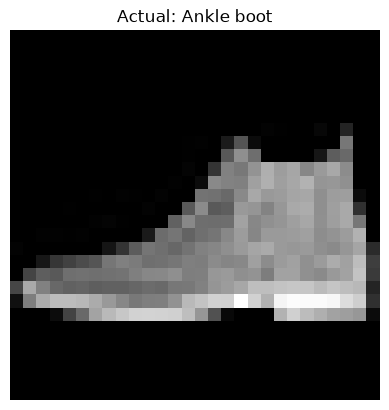

User picked image index: 0
Actual Label: Ankle boot
Model Prediction: Ankle boot


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import FashionMNIST
import matplotlib.pyplot as plt

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Data Transformation aur Loading 
transform = transforms.ToTensor()
train_data = FashionMNIST(root="data", train=True, download=True, transform=transform)
test_data = FashionMNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Model Architecture 
class FashionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 128),  
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)        
        )
    def forward(self, x):
        return self.net(x)   

model = FashionModel().to(device)

loss_fun = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Training Loop
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fun(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

# 4. Testing & Evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Total accuracy: {accuracy:.2f}%")

# to save Model 
torch.save(model.state_dict(), "fashion_model.pth")
print("Model Saved as fashion_model.pth")

# 5. Single Image Prediction and Display
index = 0
image, true_label = test_data[index]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual: {class_names[true_label]}")
plt.axis("off")
plt.show()

image_flat = image.view(1, -1).to(device)

with torch.no_grad():
    output = model(image_flat)
    predicted_label = output.argmax(dim=1).item()

print("User picked image index:", index)
print("Actual Label:", class_names[true_label])
print("Model Prediction:", class_names[predicted_label])

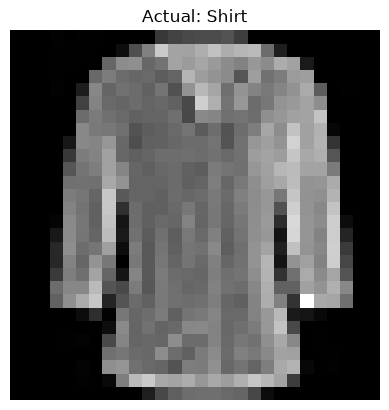

Dataset mein Shirt kis index par mili: 4
Actual Label: Shirt
Model Prediction: Shirt


In [2]:
target_class_index = 6 

for idx, (img, lbl) in enumerate(test_data):
    if lbl == target_class_index:
        index = idx
        break

image, true_label = test_data[index]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual: {class_names[true_label]}")
plt.axis("off")
plt.show()

image_flat = image.view(1, -1).to(device)

with torch.no_grad():
    output = model(image_flat)
    predicted_label = output.argmax(dim=1).item()

print("Dataset mein Shirt kis index par mili:", index)
print("Actual Label:", class_names[true_label])
print("Model Prediction:", class_names[predicted_label])